## Capital Venture Fund
This dataset consist of 50 companies data - money they invested in their R&D, Administration and Market, and how much profit generated.<br>
We want to understand how invested in these effect profit, which among 3 investment got best profit etc<br>
Or business will say- they are interested in NY companies with administration very low.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Importing dataset

In [30]:
data = pd.read_csv('50_Startups.csv')
data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [31]:
X = data.iloc[:, :-1].values
Y = data.iloc[:, -1].values

In [32]:
print(X)
print(Y)

[[165349.2 136897.8 471784.1 'New York']
 [162597.7 151377.59 443898.53 'California']
 [153441.51 101145.55 407934.54 'Florida']
 [144372.41 118671.85 383199.62 'New York']
 [142107.34 91391.77 366168.42 'Florida']
 [131876.9 99814.71 362861.36 'New York']
 [134615.46 147198.87 127716.82 'California']
 [130298.13 145530.06 323876.68 'Florida']
 [120542.52 148718.95 311613.29 'New York']
 [123334.88 108679.17 304981.62 'California']
 [101913.08 110594.11 229160.95 'Florida']
 [100671.96 91790.61 249744.55 'California']
 [93863.75 127320.38 249839.44 'Florida']
 [91992.39 135495.07 252664.93 'California']
 [119943.24 156547.42 256512.92 'Florida']
 [114523.61 122616.84 261776.23 'New York']
 [78013.11 121597.55 264346.06 'California']
 [94657.16 145077.58 282574.31 'New York']
 [91749.16 114175.79 294919.57 'Florida']
 [86419.7 153514.11 0.0 'New York']
 [76253.86 113867.3 298664.47 'California']
 [78389.47 153773.43 299737.29 'New York']
 [73994.56 122782.75 303319.26 'Florida']
 [67532

### Check missing values

In [33]:
print(data.isnull().sum())

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64


### Check categorical values
- OneHotEncoding should be done after train test split. so correct the order of this project.

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

CT = ColumnTransformer(
    transformers = [
        ('encoder', OneHotEncoder(drop='first', sparse=False), [3])
    ],
    remainder = 'passthrough'
)

X = CT.fit_transform(X)
print(X)

[[0.0 1.0 165349.2 136897.8 471784.1]
 [0.0 0.0 162597.7 151377.59 443898.53]
 [1.0 0.0 153441.51 101145.55 407934.54]
 [0.0 1.0 144372.41 118671.85 383199.62]
 [1.0 0.0 142107.34 91391.77 366168.42]
 [0.0 1.0 131876.9 99814.71 362861.36]
 [0.0 0.0 134615.46 147198.87 127716.82]
 [1.0 0.0 130298.13 145530.06 323876.68]
 [0.0 1.0 120542.52 148718.95 311613.29]
 [0.0 0.0 123334.88 108679.17 304981.62]
 [1.0 0.0 101913.08 110594.11 229160.95]
 [0.0 0.0 100671.96 91790.61 249744.55]
 [1.0 0.0 93863.75 127320.38 249839.44]
 [0.0 0.0 91992.39 135495.07 252664.93]
 [1.0 0.0 119943.24 156547.42 256512.92]
 [0.0 1.0 114523.61 122616.84 261776.23]
 [0.0 0.0 78013.11 121597.55 264346.06]
 [0.0 1.0 94657.16 145077.58 282574.31]
 [1.0 0.0 91749.16 114175.79 294919.57]
 [0.0 1.0 86419.7 153514.11 0.0]
 [0.0 0.0 76253.86 113867.3 298664.47]
 [0.0 1.0 78389.47 153773.43 299737.29]
 [1.0 0.0 73994.56 122782.75 303319.26]
 [1.0 0.0 67532.53 105751.03 304768.73]
 [0.0 1.0 77044.01 99281.34 140574.81]
 [0

c:\Users\gusai\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


### Splitting Dataset

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 0)

In [39]:
print(len(X_train))
print(len(X_test))

40
10


### Model training

In [40]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

### Predict test set results

In [41]:
y_pred = model.predict(X_test)

By deafult y_test, y_pred are all 1D array (n,). If we concat these two we will get 1D array only (8,)<br>
So we convert each to vertical 2D array (eg (4,1) and (4,1)) and concatenate to get (4,2).

In [43]:
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), Y_test.reshape(len(Y_test),1)), axis=1))

[[103015.2  103282.38]
 [132582.28 144259.4 ]
 [132447.74 146121.95]
 [ 71976.1   77798.83]
 [178537.48 191050.39]
 [116161.24 105008.31]
 [ 67851.69  81229.06]
 [ 98791.73  97483.56]
 [113969.44 110352.25]
 [167921.07 166187.94]]


### Visualization of Actual profit VS Predicted Profit
- Like in simple linear regression where we had 1 feature and 1 target, so we created a 2D graph.<br>
- But in multiple linear regression we have 4 feature and 1 target, we can't show 5D graph.<br>
- So we will create 2 vectors - one vector of actual target Y_Test and one vector of predicted target value.<br>

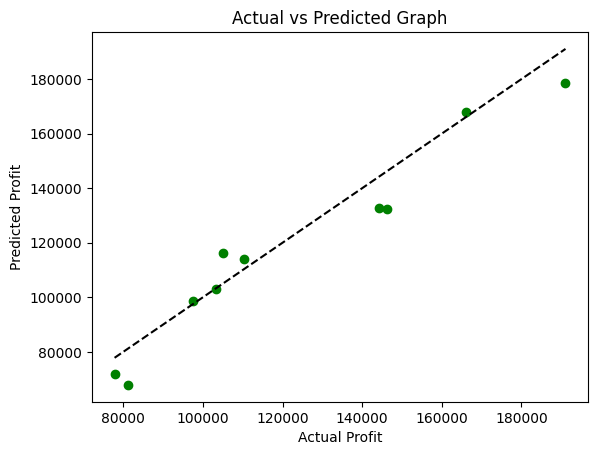

In [ ]:
plt.scatter(Y_test, y_pred, color='green')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='black', linestyle='--') # y == x
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Predicted Graph')
plt.show()

### Question1:
How do I use my multiple linear regression model to make a single prediction, for example, the profit of a startup with R&D Spend = 160000, Administration Spend = 130000, Marketing Spend = 300000 and State = California?<br>

Answer: We need to make sure our unseen input is in same order and encoding as we have in training dataset.

In [46]:
input = {
    'R&D Spend': [160000],
    'Administration': [130000],
    'Marketing Spend': [300000],
    'State': ['California']
}

input_df = pd.DataFrame(input)
print(input_df)

   R&D Spend  Administration  Marketing Spend       State
0     160000          130000           300000  California


In [49]:
input_transformed = CT.transform(input_df)
print(input_transformed)

[[     0.      0. 160000. 130000. 300000.]]


c:\Users\gusai\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(


In [48]:
predicted_profit = model.predict(input_transformed)
print(predicted_profit)

[181566.92]


### Question2:
How do I get the final regression equation y = b0 + b1 x1 + b2 x2 + … with the final values of the coefficients?

In [ ]:
b0 = model.intercept_
print('Intercept Value of trained model:\t', b0)


print('\nBelow are the features and their calculated coefficient:')
features = ['State_New York', 'State_Florida', 'R&D Spend', 'Administration', 'Marketing Spend']
equation = f"y = {b0:.2f}"

for feature, coef in zip(features, model.coef_):
    print(f'{feature}\t{coef:.2f}')
    equation += f" + ({coef:.2f}*{feature})" 

print('\n',equation)

Intercept Value of trained model:	 42554.16761774017

Below are the features and their calculated coefficient:
State_New York	-959.28
State_Florida	699.37
R&D Spend	0.77
Administration	0.03
Marketing Spend	0.04

 y = 42554.17 + (-959.28*State_New York) + (699.37*State_Florida) + (0.77*R&D Spend) + (0.03*Administration) + (0.04*Marketing Spend)
